In [1]:

import collections.abc
import matplotlib
# parche para reintroducir cbook.iterable
import matplotlib.cbook as cbook
cbook.iterable = lambda x: isinstance(x, collections.abc.Iterable)
import networkx as nx
import matplotlib.pyplot as plt

In [14]:
def draw_graph(G):
    pos = nx.spring_layout(G, k=1.0, iterations=100, seed=42)

    plt.figure(figsize=(12, 12))
    nx.draw_networkx_nodes(
        G, pos,
        node_color="#ffca28",
        node_size=1500,
        edgecolors="black"
    )
    nx.draw_networkx_labels(
        G, pos,
        font_size=8,
        font_family="sans-serif"
    )
    nx.draw_networkx_edges(
        G, pos,
        arrowstyle='->',
        arrowsize=40,
        width=1.2,
        connectionstyle='arc3,rad=0.1'
    )

    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_color='gray',
        font_size=6
    )

    plt.title("Grafo de llamadas y conexiones de 'firefox' y su cache")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

3.1.5

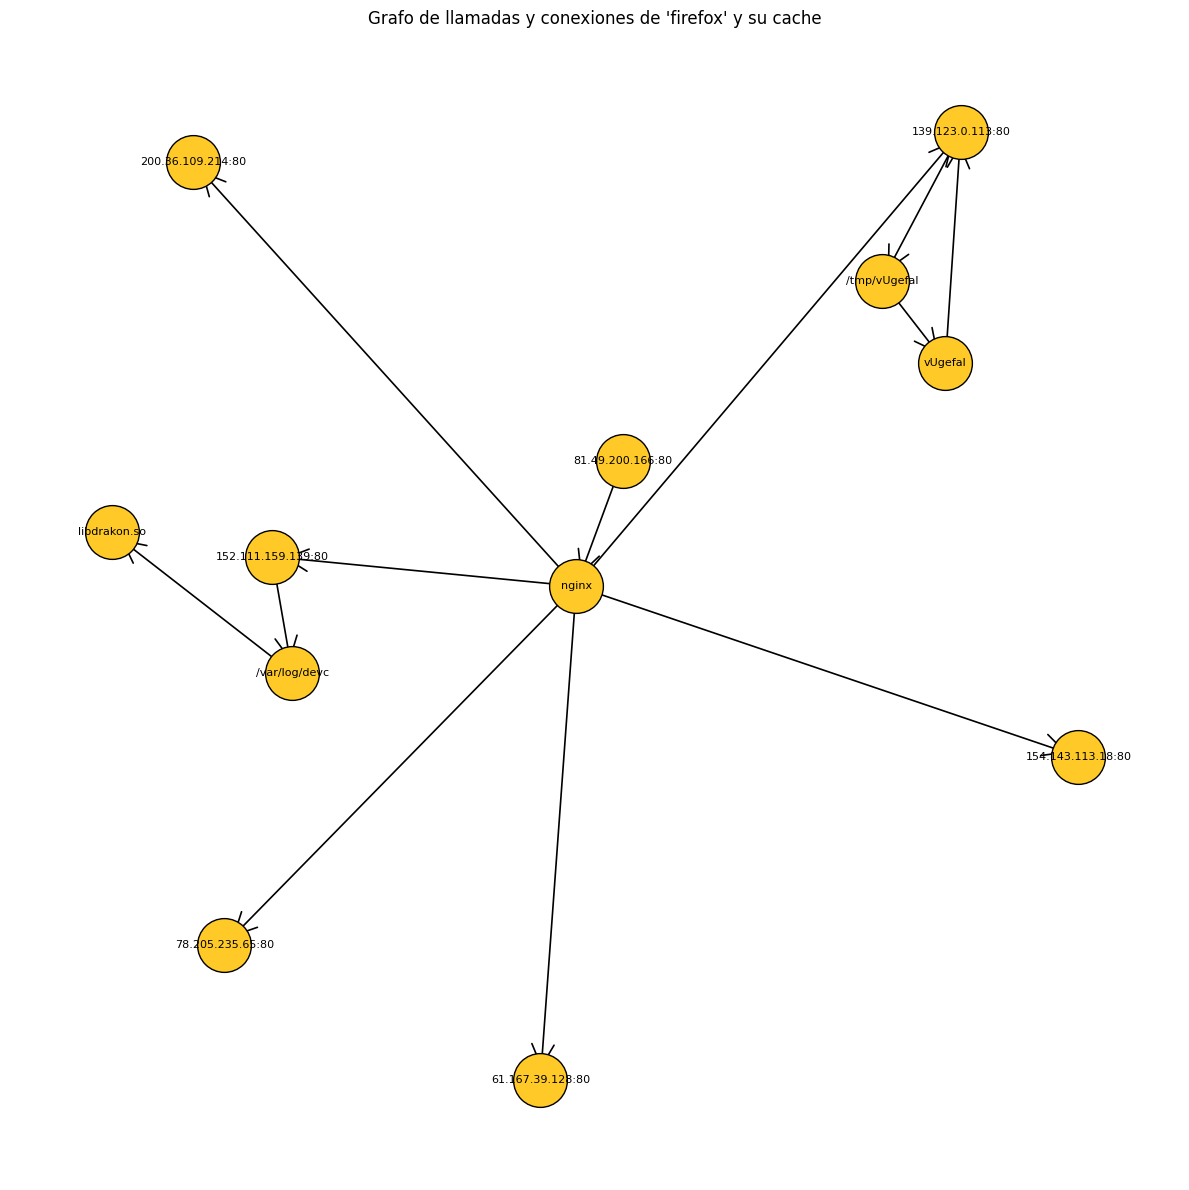

In [38]:
# NetworkX recreation of the “3.1.5 Graph” (Nginx back‑door)  
# Sources: Section 3.1.3 “Addresses” and 3.1.4 “Interactions” of the report :contentReference[oaicite:0]{index=0}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ───────────────────────────────────────────────────────────────────────
G.add_node("81.49.200.166:80",        shape="diamond")   # exploit host
G.add_node("nginx",                   shape="rectangle")
G.add_node("78.205.235.65:80",        shape="diamond")   # shellcode_server
G.add_node("200.36.109.214:80",       shape="diamond")   # loaderDrakon server
G.add_node("139.123.0.113:80",        shape="diamond")   # drakon server
G.add_node("152.111.159.139:80",      shape="diamond")   # libdrakon server
G.add_node("154.143.113.18:80",       shape="diamond")   # netrecon (fail)
G.add_node("61.167.39.128:80",        shape="diamond")   # netrecon (success)
G.add_node("/tmp/vUgefal",            shape="ellipse")   # staged binary on disk
G.add_node("/var/log/devc",           shape="ellipse")   # staged .so on disk
G.add_node("vUgefal",                 shape="rectangle") # elevated drakon process
G.add_node("libdrakon.so",            shape="rectangle") # injected .so process

# ── Edges ───────────────────────────────────────────────────────────────────────
G.add_edge("81.49.200.166:80", "nginx",               action="connect")
G.add_edge("nginx", "78.205.235.65:80",               action="connect")
G.add_edge("nginx", "200.36.109.214:80",              action="connect")
G.add_edge("nginx", "139.123.0.113:80",               action="connect")
G.add_edge("nginx", "152.111.159.139:80",             action="connect")
G.add_edge("nginx", "154.143.113.18:80",              action="connect???")  # failed nrtcp
G.add_edge("nginx", "61.167.39.128:80",               action="connect")
G.add_edge("139.123.0.113:80", "/tmp/vUgefal",        action="write")       # putfile
G.add_edge("/tmp/vUgefal", "vUgefal",                 action="execute")     # elevate/exec
G.add_edge("152.111.159.139:80", "/var/log/devc",     action="write")       # putfile
G.add_edge("/var/log/devc", "libdrakon.so",           action="execute")     # inject
G.add_edge("vUgefal", "139.123.0.113:80",            action="send???")     # C2 callback



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_1.gml")

3.2.5

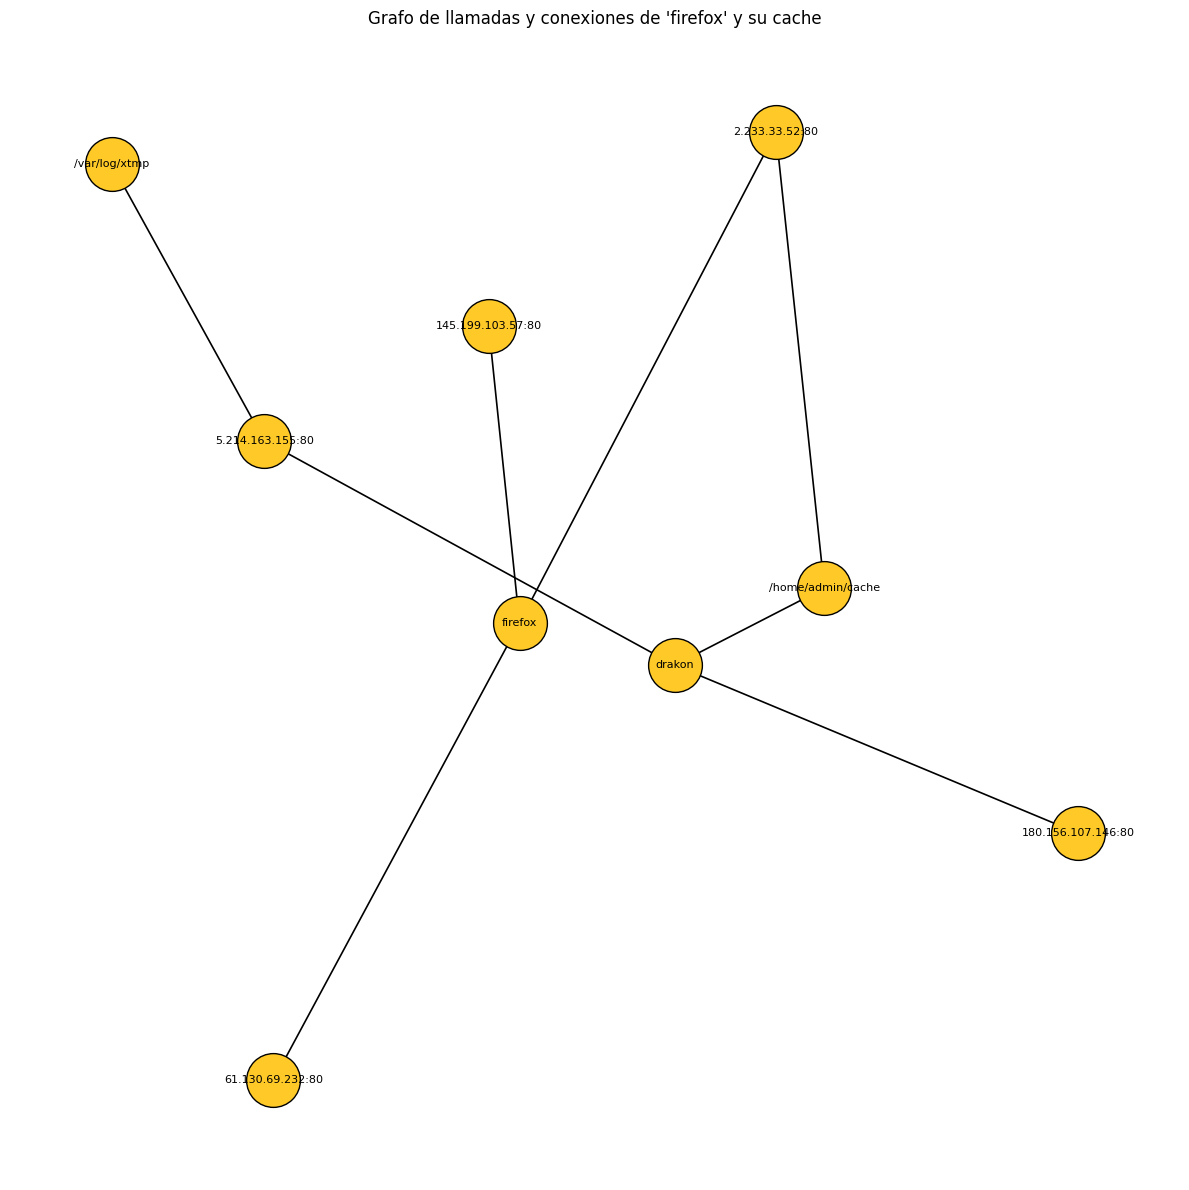

In [ ]:
# NetworkX recreation of the “3.2 Graph” (TRACE Firefox back‑door)
# Sources: 3.2.3 Addresses & 3.2.4 Interactions of the report :contentReference[oaicite:0]{index=0}:contentReference[oaicite:1]{index=1}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ───────────────────────────────────────────────────────────────────────
G.add_node("145.199.103.57:80",  shape="diamond")   # exploit web‑ad host
G.add_node("firefox",            shape="rectangle")
G.add_node("61.130.69.232:80",  shape="diamond")   # shellcode_server
G.add_node("2.233.33.52:80",    shape="diamond")   # loaderDrakon server
G.add_node("/home/admin/cache", shape="ellipse")   # staged drakon binary
G.add_node("drakon",            shape="rectangle") # elevated drakon process
G.add_node("180.156.107.146:80",shape="diamond")   # drakon C2
G.add_node("5.214.163.155:80",  shape="diamond")   # libdrakon host
G.add_node("/var/log/xtmp",     shape="ellipse")   # staged .so on disk

# ── Edges ───────────────────────────────────────────────────────────────────────
G.add_edge("145.199.103.57:80", "firefox",               action="connect")
G.add_edge("firefox",            "61.130.69.232:80",      action="connect")
G.add_edge("firefox",            "2.233.33.52:80",        action="connect")
G.add_edge("2.233.33.52:80",     "/home/admin/cache",     action="write")
G.add_edge("/home/admin/cache",  "drakon",                action="execute")
G.add_edge("drakon",             "180.156.107.146:80",    action="connect???")  # C2 callback
G.add_edge("drakon",             "5.214.163.155:80",      action="connect???")  # retrieve .so
G.add_edge("5.214.163.155:80",   "/var/log/xtmp",         action="write")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_2.gml")


3.3.5

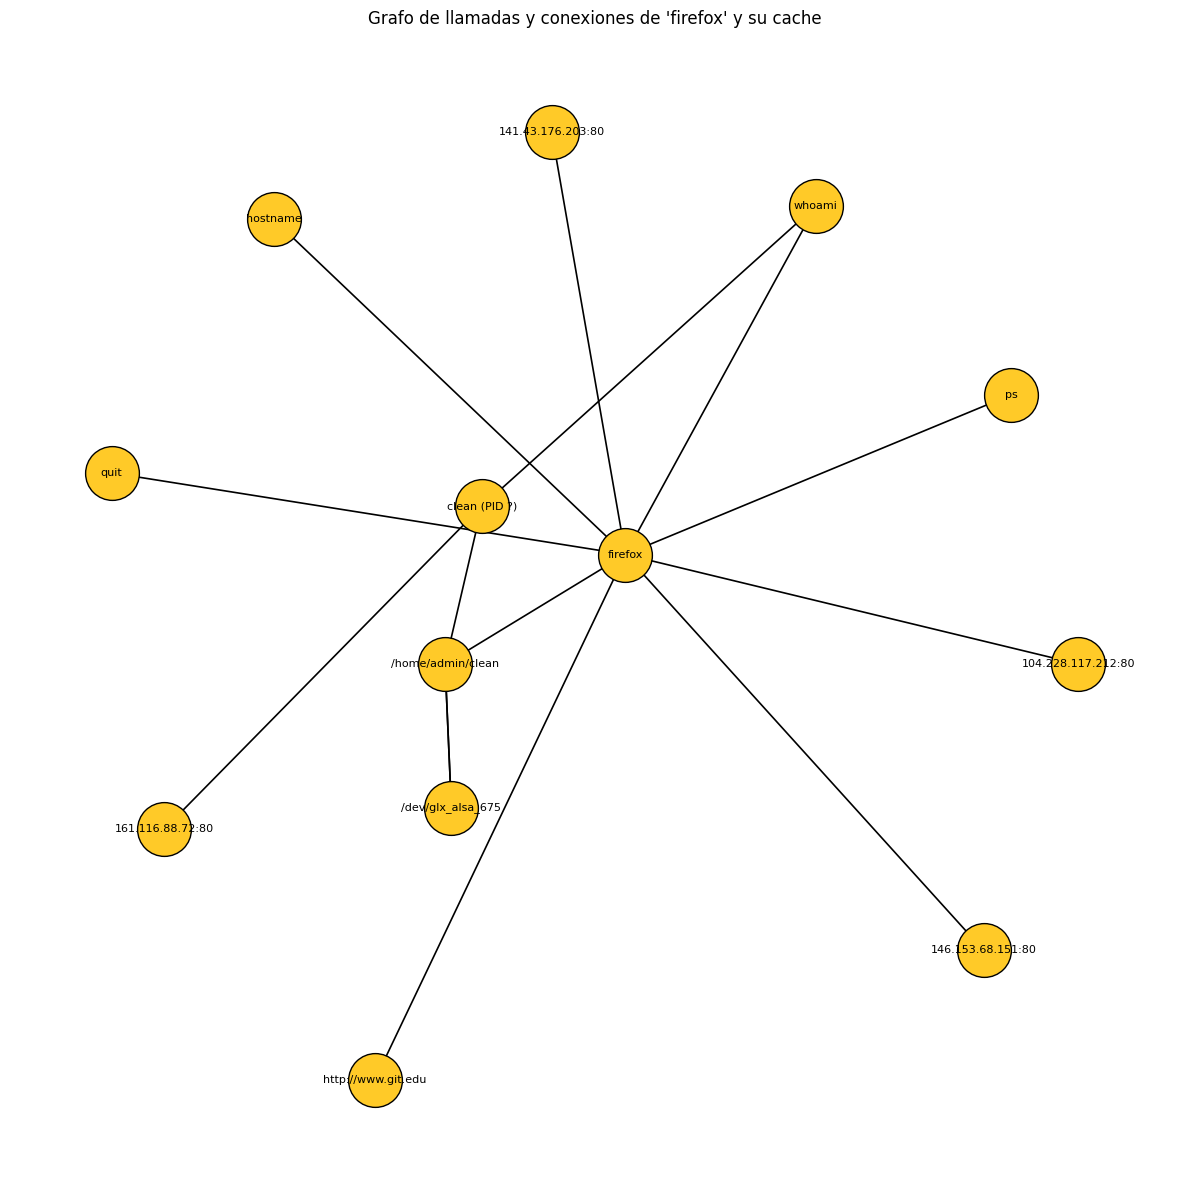

In [ ]:
# NetworkX recreation of the “3.3 Graph” (THEIA – Firefox back‑door)
# Sources: 3.3.3 Addresses & 3.3.4 Interactions in the report :contentReference[oaicite:0]{index=0}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ───────────────────────────────────────────────────────────────────────
G.add_node("145.199.103.57:80",   shape="diamond")   # www.allstate.com exploit host
G.add_node("104.228.117.212:80", shape="diamond")   # www.gatech.edu exploit host
G.add_node("firefox",             shape="rectangle")

G.add_node("61.130.69.232:80",   shape="diamond")   # shellcode_server 1
G.add_node("141.43.176.203:80",  shape="diamond")   # shellcode_server 2
G.add_node("146.153.68.151:80",  shape="diamond")   # loaderDrakon
G.add_node("161.116.88.72:80",   shape="diamond")   # drakon server
G.add_node("7.149.198.40:80",    shape="diamond")   # netrecon

G.add_node("/tmp/clean",         shape="ellipse")   # staged drakon binary
G.add_node("clean",              shape="rectangle") # elevated drakon process

G.add_node("/home/admin/profile",shape="ellipse")   # 2nd staged binary
G.add_node("profile",            shape="rectangle") # 2nd drakon process

G.add_node("/var/log/xdev",      shape="ellipse")   # staged .so
G.add_node("5.214.163.155:80",   shape="diamond")   # libdrakon server

# ── Edges ───────────────────────────────────────────────────────────────────────
# initial exploits
G.add_edge("145.199.103.57:80", "firefox",               action="connect")
G.add_edge("104.228.117.212:80","firefox",               action="connect")

# shellcode & payload retrieval
G.add_edge("firefox", "61.130.69.232:80",                action="connect")
G.add_edge("firefox", "141.43.176.203:80",               action="connect")
G.add_edge("firefox", "146.153.68.151:80",               action="connect")

# binaries written to disk
G.add_edge("161.116.88.72:80", "/tmp/clean",             action="write")
G.add_edge("161.116.88.72:80", "/home/admin/profile",    action="write")
G.add_edge("5.214.163.155:80", "/var/log/xdev",          action="write")

# execution / privilege‑escalation of binaries
G.add_edge("/tmp/clean",          "clean",               action="execute")
G.add_edge("/home/admin/profile", "profile",             action="execute")

# outbound C2 / recon connections
G.add_edge("profile", "161.116.88.72:80",                action="connect")
G.add_edge("profile", "7.149.198.40:80",                 action="connect???")  # nrtcp



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_3.gml")

3.4.5

In [ ]:
# NetworkX recreation of the “3.4 Graph” (FiveDirections Firefox back‑door)
# Sources: 3.4.3 Addresses & 3.4.4 Connections of the report :contentReference[oaicite:0]{index=0}:contentReference[oaicite:1]{index=1}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ───────────────────────────────────────────────────────────────────────
G.add_node("179.252.65.246:80",  shape="diamond")   # exploit webserver (www.cnpc.com.cn)
G.add_node("firefox",            shape="rectangle")
G.add_node("156.78.147.114:80",  shape="diamond")   # shellcode_server
G.add_node("16.54.116.146:80",   shape="diamond")   # loaderDrakon
G.add_node("drakon",             shape="rectangle") # implant running inside Firefox
G.add_node("193.189.212.26:80",  shape="diamond")   # netrecon exfil (TCP)
G.add_node("27.56.56.211:80",    shape="diamond")   # netrecon exfil (UDP)

# ── Edges ───────────────────────────────────────────────────────────────────────
G.add_edge("179.252.65.246:80", "firefox",            action="connect")
G.add_edge("firefox",            "156.78.147.114:80",  action="connect")
G.add_edge("firefox",            "16.54.116.146:80",   action="connect")
G.add_edge("firefox",            "drakon",             action="execute???")  # in‑memory load
G.add_edge("drakon",             "193.189.212.26:80",  action="send???")     # netrecon tcp exfil
G.add_edge("drakon",             "27.56.56.211:80",    action="send???")     # netrecon udp exfil


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_4.gml")

3.6.5

In [ ]:
# NetworkX recreation of the “3.6 Graph” (ClearScope Firefox back‑door)
# Sources: 3.6.3 Addresses & 3.6.4 Interactions :contentReference[oaicite:0]{index=0}:contentReference[oaicite:1]{index=1}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ──────────────────────────────────────────────────────────────
G.add_node("153.178.46.202:80",  shape="diamond")   # exploit webserver
G.add_node("firefox",            shape="rectangle")
G.add_node("111.82.111.27:80",   shape="diamond")   # shellcode_server
G.add_node("166.199.230.185:80", shape="diamond")   # loaderDrakon
G.add_node("188.167.106.122:80", shape="diamond")   # libdrakon host
G.add_node("140.57.183.17:80",   shape="diamond")   # drakon C2
G.add_node("193.72.18.131:80",   shape="diamond")   # netrecon (failed)

G.add_node("/data/data/org.mozilla.fennec_firefox_dev/shared_files",
           shape="ellipse")                         # staged drakon binary
G.add_node("/data/data/org.mozilla.fennec_firefox_dev/csb.tracee.27331.27355",
           shape="ellipse")                         # staged .so
G.add_node("shared_files",        shape="rectangle") # elevated drakon proc

# ── Edges ───────────────────────────────────────────────────────────────
G.add_edge("153.178.46.202:80", "firefox",                        action="connect")
G.add_edge("firefox",            "111.82.111.27:80",              action="connect")
G.add_edge("firefox",            "166.199.230.185:80",            action="connect")
G.add_edge("firefox",            "188.167.106.122:80",            action="connect???")  # failed
G.add_edge("firefox",            "193.72.18.131:80",              action="connect???")  # netrecon
G.add_edge("140.57.183.17:80",
           "/data/data/org.mozilla.fennec_firefox_dev/shared_files",
           action="write")
G.add_edge("188.167.106.122:80",
           "/data/data/org.mozilla.fennec_firefox_dev/csb.tracee.27331.27355",
           action="write")
G.add_edge("/data/data/org.mozilla.fennec_firefox_dev/shared_files",
           "shared_files",                             action="execute")
G.add_edge("/data/data/org.mozilla.fennec_firefox_dev/csb.tracee.27331.27355",
           "shared_files",                             action="execute???")  # inject (failed)
G.add_edge("shared_files",      "140.57.183.17:80",   action="connect???")   # C2
G.add_edge("shared_files",      "193.72.18.131:80",   action="send???")      # netrecon



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_6.gml")

3.8.5

In [ ]:
# NetworkX recreation of the “3.8 Graph”  
# (CADETS – Nginx back‑door with Drakon in memory, 11 Apr 2018 15:00)  
# Info drawn from 3.8.3 Addresses, 3.8.4 Interactions and 3.8.5 Graph sections :contentReference[oaicite:0]{index=0}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ──────────────────────────────────────────────────────────────
G.add_node("25.159.96.207:80",  shape="diamond")   # exploit host (HTTP POST)
G.add_node("nginx",             shape="rectangle") # target web‑server (Drakon in‑mem)
G.add_node("76.56.184.25:80",   shape="diamond")   # shellcode_server
G.add_node("155.162.39.48:80",  shape="diamond")   # loaderDrakon
G.add_node("198.115.236.119:80",shape="diamond")   # libdrakon host
G.add_node("/tmp/grain",        shape="ellipse")   # staged .so on disk
G.add_node("sendmail",          shape="ellipse")   # failed file drop (uncertain)
G.add_node("sshd",              shape="rectangle") # intended injection target

# ── Edges ───────────────────────────────────────────────────────────────
G.add_edge("25.159.96.207:80",  "nginx",              action="connect")
G.add_edge("nginx",             "76.56.184.25:80",    action="connect")
G.add_edge("nginx",             "155.162.39.48:80",   action="connect")
G.add_edge("nginx",             "198.115.236.119:80", action="connect???")  # assumed fetch
G.add_edge("198.115.236.119:80","/tmp/grain",         action="write")
G.add_edge("198.115.236.119:80","sendmail",           action="write???")    # failed putfile
G.add_edge("/tmp/grain",        "sshd",               action="execute???")  # inject (failed)


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_8.gml")

3.10.5

In [ ]:
# NetworkX recreation of the “3.10 Graph” (FiveDirections browser‑extension dropper)
# Sources: 3.10.3 Addresses & 3.10.4 Interactions of the report :contentReference[oaicite:0]{index=0}:contentReference[oaicite:1]{index=1}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ───────────────────────────────────────────────────────────────
G.add_node("132.85.63.248:80", shape="diamond")   # exploit webserver
G.add_node("firefox",           shape="rectangle")
G.add_node("135.84.161.202:80", shape="diamond")   # shellcode_server
G.add_node("hJauWl01",         shape="ellipse")    # drakon implant on disk
G.add_node("drakon",           shape="rectangle")  # attempted implant process
G.add_node("221.205.132.182:80",shape="diamond")   # drakon C2 (failed)

# ── Edges ───────────────────────────────────────────────────────────────
G.add_edge("132.85.63.248:80", "firefox",           action="connect")
G.add_edge("firefox",          "135.84.161.202:80", action="connect")
G.add_edge("135.84.161.202:80","hJauWl01",          action="write")
G.add_edge("hJauWl01",         "drakon",            action="execute???")  # crashed
G.add_edge("drakon",           "221.205.132.182:80",action="connect???") # no callback


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_10.gml")

3.11.7

In [ ]:
import networkx as nx

# Graph 3.11 – THEIA Browser Extension w/ Drakon Dropper
G = nx.DiGraph()

# --- NODES ------------------------------------------------------------------
nodes = {
    # processes
    "firefox": "rectangle",
    "gtcache": "rectangle",          # Drakon APT proc
    "micro_apt": "rectangle",
    "sshd": "rectangle",

    # files
    "xdev": "ellipse",
    "wdev": "ellipse",
    "memtrace.so": "ellipse",
    "mail": "ellipse",

    # external connections (IPs/URLs)
    "104.228.117.212:80": "diamond",   # webserver (www.gatech.edu)
    "141.43.176.203:80": "diamond",    # shellcode_server
    "146.153.68.151:80": "diamond",    # loaderDrakon host
    "149.52.198.23:80": "diamond",     # micro C2
    "5.214.163.155:80": "diamond"      # libdrakon host
}

for n, shape in nodes.items():
    G.add_node(n, shape=shape)

# --- EDGES ------------------------------------------------------------------
edges = [
    # Firefox exploit traffic
    ("firefox", "104.228.117.212:80", "connect"),
    ("firefox", "141.43.176.203:80", "connect"),

    # Drakon APT (gtcache) C2
    ("gtcache", "146.153.68.151:80", "connect"),

    # libdrakon dropped, attempted injection
    ("5.214.163.155:80", "memtrace.so", "write"),
    ("memtrace.so", "sshd", "execute???"),

    # micro APT dropped & run
    ("149.52.198.23:80", "mail", "write"),
    ("mail", "micro_apt", "execute"),
    ("micro_apt", "149.52.198.23:80", "connect"),

    # local file copy & failed injections
    ("xdev", "wdev", "create"),
    ("xdev", "sshd", "execute???"),
    ("wdev", "sshd", "execute???")
]

for u, v, action in edges:
    G.add_edge(u, v, action=action)



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_11.gml")

3.13.6

In [ ]:

# NetworkX recreation of “3.13 Graph”  
# (2018‑04‑12 14:00 CADETS – Nginx back‑door w/ Drakon in‑memory)  :contentReference[oaicite:0]{index=0}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ──────────────────────────────────────────────────────────────────
G.add_node("25.159.96.207:80",  shape="diamond")   # exploit host
G.add_node("nginx",             shape="rectangle")
G.add_node("76.56.184.25:80",   shape="diamond")   # shellcode server
G.add_node("155.162.39.48:80",  shape="diamond")   # loaderDrakon
G.add_node("198.115.236.119:80",shape="diamond")   # libdrakon host (failed)
G.add_node("53.158.101.118:80", shape="diamond")   # drakon host
G.add_node("98.15.44.232:80",   shape="diamond")   # micro APT host #1 (failed)
G.add_node("192.113.144.28:80", shape="diamond")   # micro APT host #2

G.add_node("/tmp/font",         shape="ellipse")
G.add_node("/tmp/XIM",          shape="ellipse")
G.add_node("/tmp/tmux-1002",    shape="ellipse")
G.add_node("/var/log/sendmail", shape="ellipse")

G.add_node("XIM",               shape="rectangle")  # elevated drakon proc
G.add_node("sendmail",          shape="rectangle")  # micro APT proc

# ── Edges ──────────────────────────────────────────────────────────────────
# exploitation & outbound fetches
G.add_edge("25.159.96.207:80", "nginx",               action="connect")
G.add_edge("nginx",            "76.56.184.25:80",     action="connect")
G.add_edge("nginx",            "155.162.39.48:80",    action="connect")
G.add_edge("nginx",            "198.115.236.119:80",  action="connect???")   # libdrakon fetch

# file drops
G.add_edge("198.115.236.119:80","/tmp/font",          action="write")
G.add_edge("53.158.101.118:80", "/tmp/XIM",           action="write")
G.add_edge("98.15.44.232:80",   "/tmp/tmux-1002",     action="write")
G.add_edge("192.113.144.28:80", "/var/log/sendmail",  action="write")

# executions / processes
G.add_edge("/tmp/XIM",          "XIM",                action="execute")
G.add_edge("/var/log/sendmail", "sendmail",           action="execute")
# attempted but failed privilege‑escalation runs
G.add_edge("/tmp/tmux-1002",    "tmux-1002???",       action="execute???")

# C2 / follow‑on traffic
G.add_edge("XIM",      "53.158.101.118:80", action="connect")
G.add_edge("sendmail", "192.113.144.28:80", action="connect")




draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_13.gml")


3.14.5

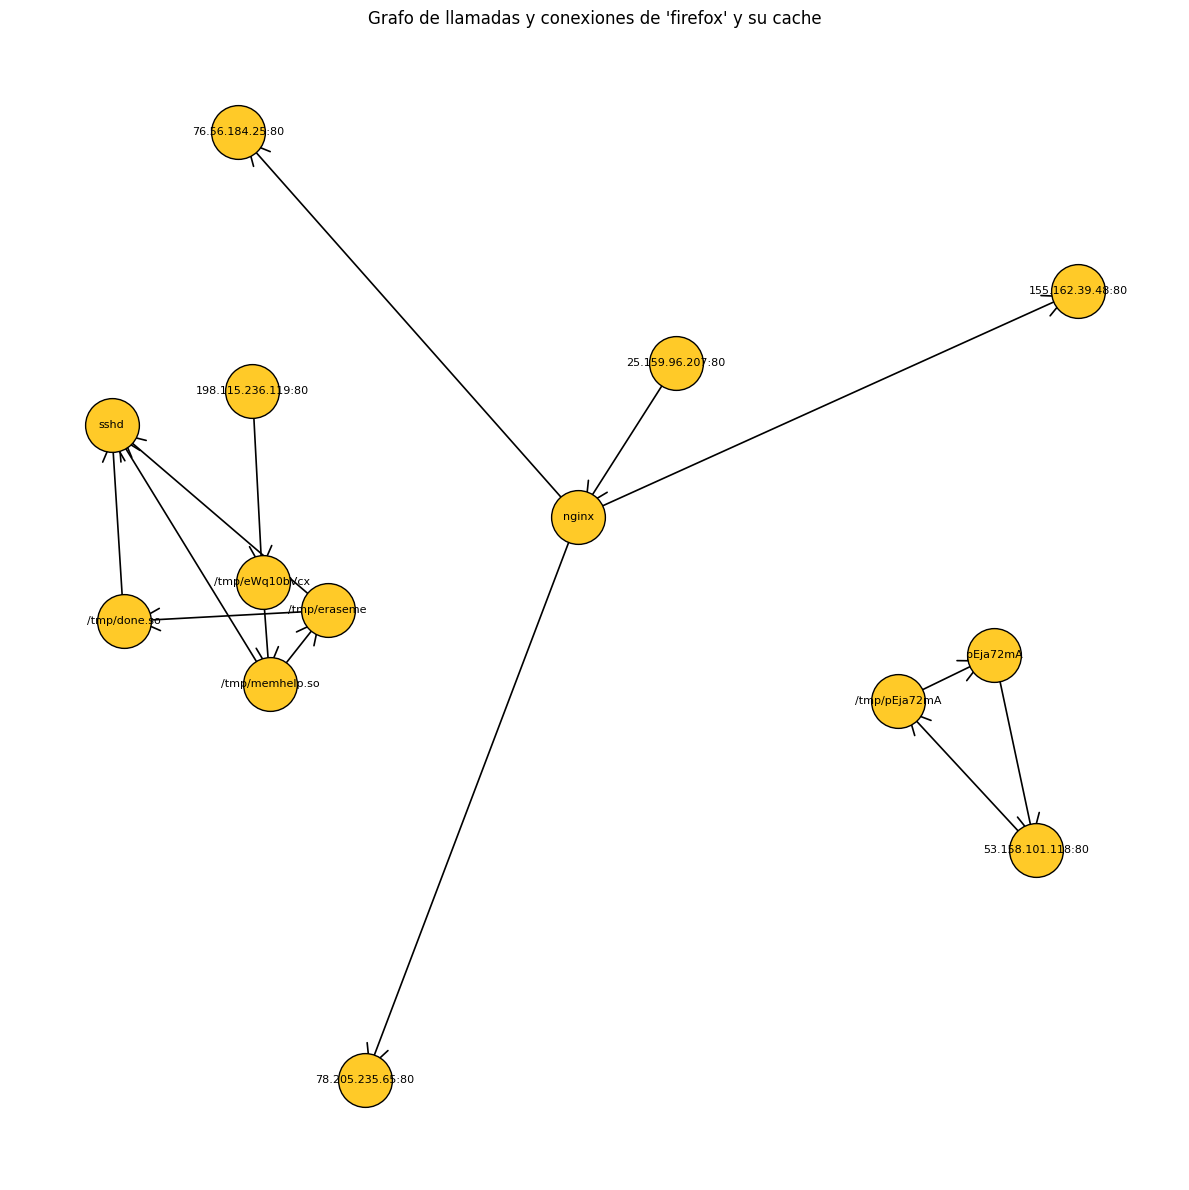

In [ ]:
# NetworkX recreation of the “3.14 Graph” (CADETS – Nginx back‑door, 13 Apr 2018)  :contentReference[oaicite:0]{index=0}:contentReference[oaicite:1]{index=1}
import networkx as nx

G = nx.DiGraph()

# ── Nodes ───────────────────────────────────────────────────────────────────────
G.add_node("25.159.96.207:80",      shape="diamond")     # exploit host
G.add_node("nginx",                 shape="rectangle")
G.add_node("78.205.235.65:80",      shape="diamond")     # shellcode_server #2
G.add_node("76.56.184.25:80",       shape="diamond")     # shellcode_server #1
G.add_node("155.162.39.48:80",      shape="diamond")     # loaderDrakon
G.add_node("198.115.236.119:80",    shape="diamond")     # libdrakon host
G.add_node("53.158.101.118:80",     shape="diamond")     # drakon host / C2

G.add_node("/tmp/pEja72mA",         shape="ellipse")     # staged drakon binary
G.add_node("/tmp/eWq10bVcx",        shape="ellipse")     # staged .so
G.add_node("/tmp/memhelp.so",       shape="ellipse")
G.add_node("/tmp/eraseme",          shape="ellipse")
G.add_node("/tmp/done.so",          shape="ellipse")
G.add_node("/etc/passwd",          shape="ellipse")
G.add_node("/etc/passwd",          shape="ellipse")

G.add_node("pEja72mA",              shape="rectangle")   # elevated drakon proc
G.add_node("sshd",                  shape="rectangle")   # target injection proc

# ── Edges ───────────────────────────────────────────────────────────────────────
# exploitation & outbound fetches
G.add_edge("25.159.96.207:80", "nginx",                  action="connect")

G.add_edge("nginx", "/etc/passwd", action="read")

G.add_edge("nginx",            "78.205.235.65:80",       action="connect")
G.add_edge("nginx",            "76.56.184.25:80",        action="connect")
G.add_edge("nginx",            "155.162.39.48:80",       action="connect")

# file drops
G.add_edge("53.158.101.118:80", "/tmp/pEja72mA",         action="write")
G.add_edge("198.115.236.119:80","/tmp/eWq10bVcx",        action="write")

# local copies of the .so (cp commands)
G.add_edge("/tmp/eWq10bVcx",    "/tmp/memhelp.so",       action="create")
G.add_edge("/tmp/memhelp.so",   "/tmp/eraseme",          action="create")
G.add_edge("/tmp/eraseme",      "/tmp/done.so",          action="create")

# execution / processes
G.add_edge("/tmp/pEja72mA",     "pEja72mA",              action="execute")
G.add_edge("pEja72mA",          "53.158.101.118:80",     action="connect")

# attempted injections into sshd
G.add_edge("/tmp/memhelp.so",   "sshd",                  action="execute???")
G.add_edge("/tmp/eraseme",      "sshd",                  action="execute???")
G.add_edge("/tmp/done.so",      "sshd",                  action="execute???")


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_14.gml")

3.15.4

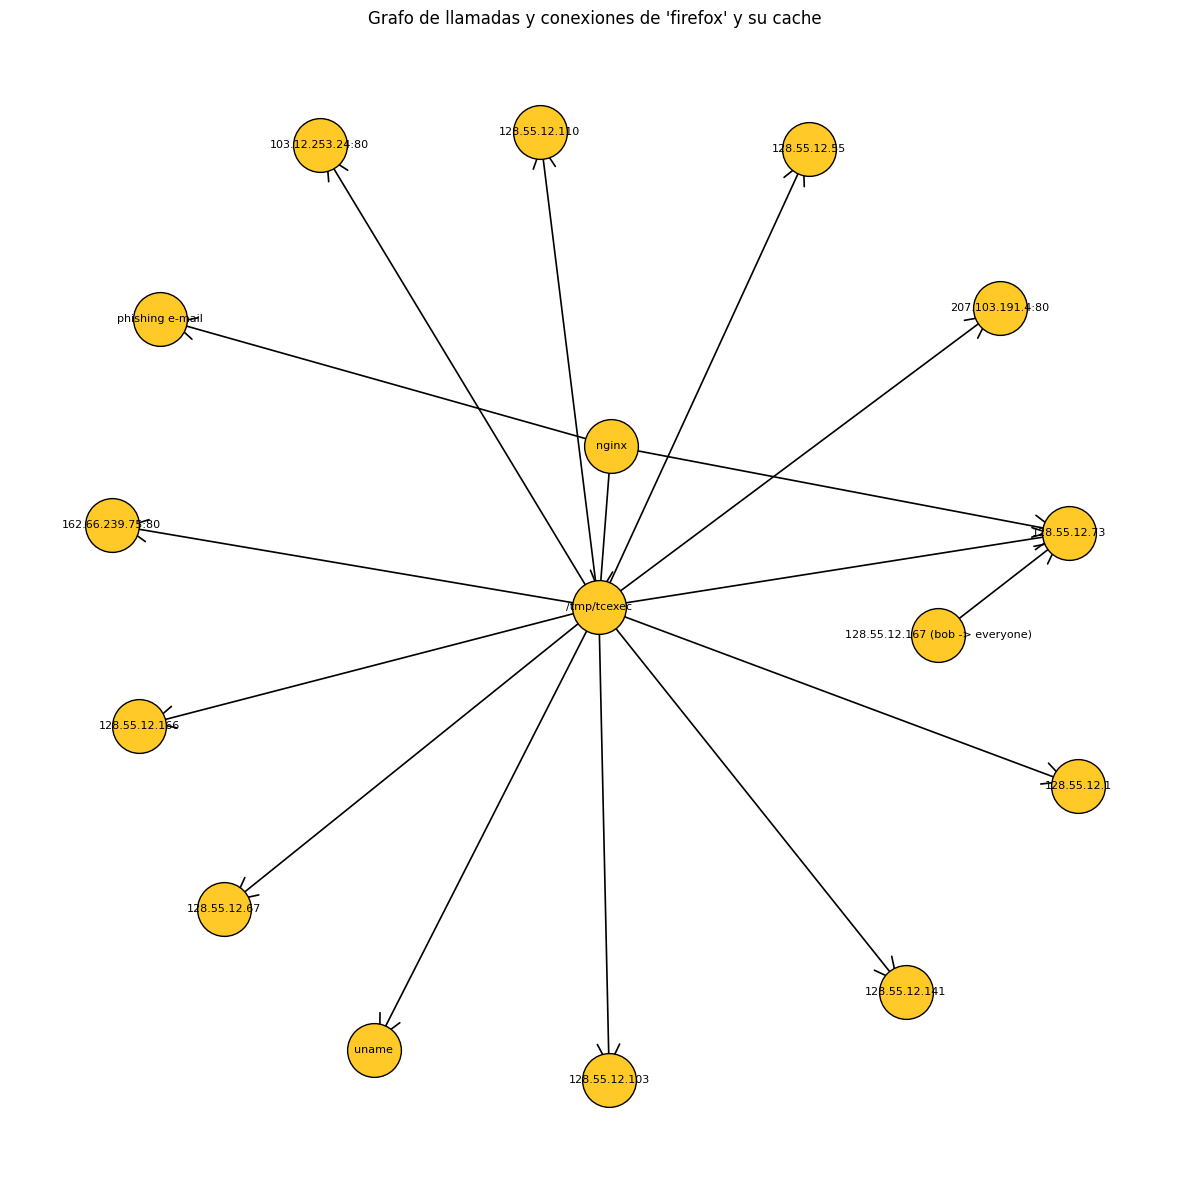

In [36]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Procesos
G.add_node("nginx",            shape="rectangle")
G.add_node("/tmp/tcexec",     shape="rectangle")
G.add_node("uname",           shape="rectangle")

# Ficheros
G.add_node("phishing e-mail", shape="ellipse")

# IPs y URLs (conexiones)
G.add_node("207.103.191.4:80",           shape="diamond")
G.add_node("103.12.253.24:80",           shape="diamond")
G.add_node("128.55.12.1",                shape="diamond")
G.add_node("128.55.12.67",               shape="diamond")
G.add_node("128.55.12.110",              shape="diamond")
G.add_node("128.55.12.103",              shape="diamond")
G.add_node("128.55.12.141",              shape="diamond")
G.add_node("128.55.12.166",              shape="diamond")
G.add_node("128.55.12.55",               shape="diamond")
G.add_node("162.66.239.75:80",           shape="diamond")
G.add_node("128.55.12.167 (bob -> everyone)", shape="diamond")
G.add_node("128.55.12.73",               shape="diamond")

# --- ARISTAS con atributo "action" ---
# Flujo inicial de nginx
G.add_edge("nginx",            "phishing e-mail",             action="read")
G.add_edge("nginx",            "/tmp/tcexec",                 action="execute")
G.add_edge("nginx",            "128.55.12.73", action="connect")

# Conexiones fallidas desde /tmp/tcexec
for target in ["207.103.191.4:80", "103.12.253.24:80", "128.55.12.1", "128.55.12.67",
                "128.55.12.110", "128.55.12.103", "128.55.12.141", "128.55.12.166", "128.55.12.55", "162.66.239.75:80"]:
    G.add_edge("/tmp/tcexec", target, action="connect")

# Port scans de primer nivel
G.add_edge("/tmp/tcexec",  "uname",        action="execute")

# Port scan directo al final
G.add_edge("/tmp/tcexec",   "128.55.12.73", action="connect")

# Conexión SMTP desde el servidor de correo
G.add_edge("128.55.12.167 (bob -> everyone)", "128.55.12.73", action="connect")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_15.gml")

4.1.5

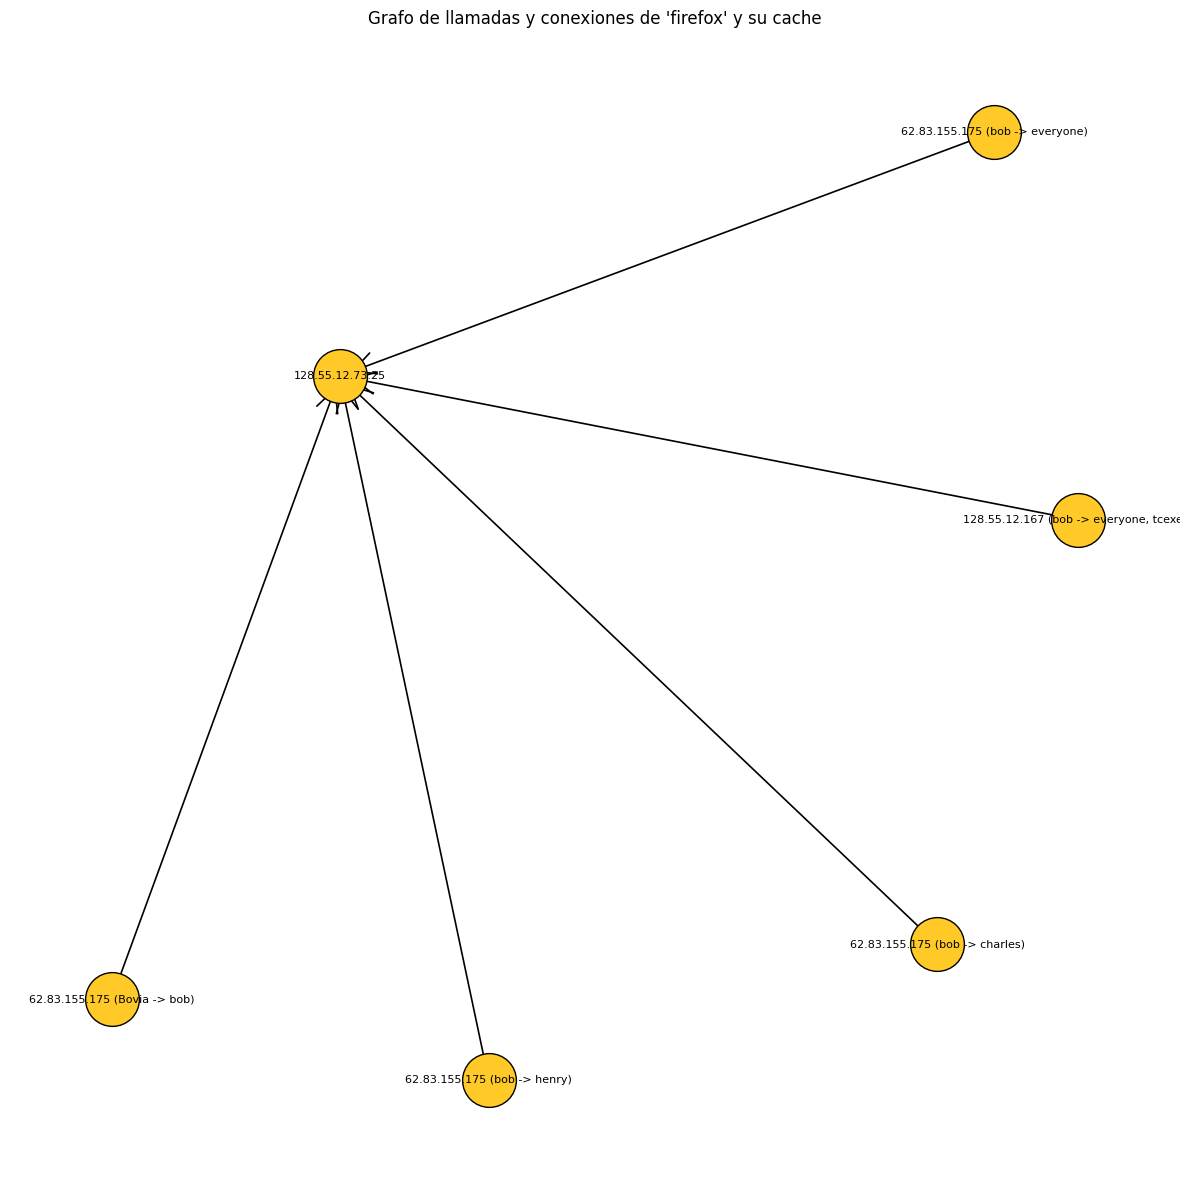

In [34]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Conexiones/IPs
G.add_node("62.83.155.175 (bob -> everyone)",   shape="diamond")
G.add_node("62.83.155.175 (bob -> charles)",    shape="diamond")
G.add_node("62.83.155.175 (bob -> henry)",      shape="diamond")
G.add_node("62.83.155.175 (Bovia -> bob)",      shape="diamond")
G.add_node("128.55.12.167 (bob -> everyone, tcexec)", shape="diamond")

# --- ARISTAS con atributo "action" ---
# Todas las flechas llegan al nodo "connect (smtp)" con la misma etiqueta de puerto
for src in [
    "62.83.155.175 (bob -> everyone)",
    "62.83.155.175 (bob -> charles)",
    "62.83.155.175 (bob -> henry)",
    "62.83.155.175 (Bovia -> bob)",
    "128.55.12.167 (bob -> everyone, tcexec)"
]:
    G.add_edge(src, "128.55.12.73:25", action="connect")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_1.gml")

4.2.6

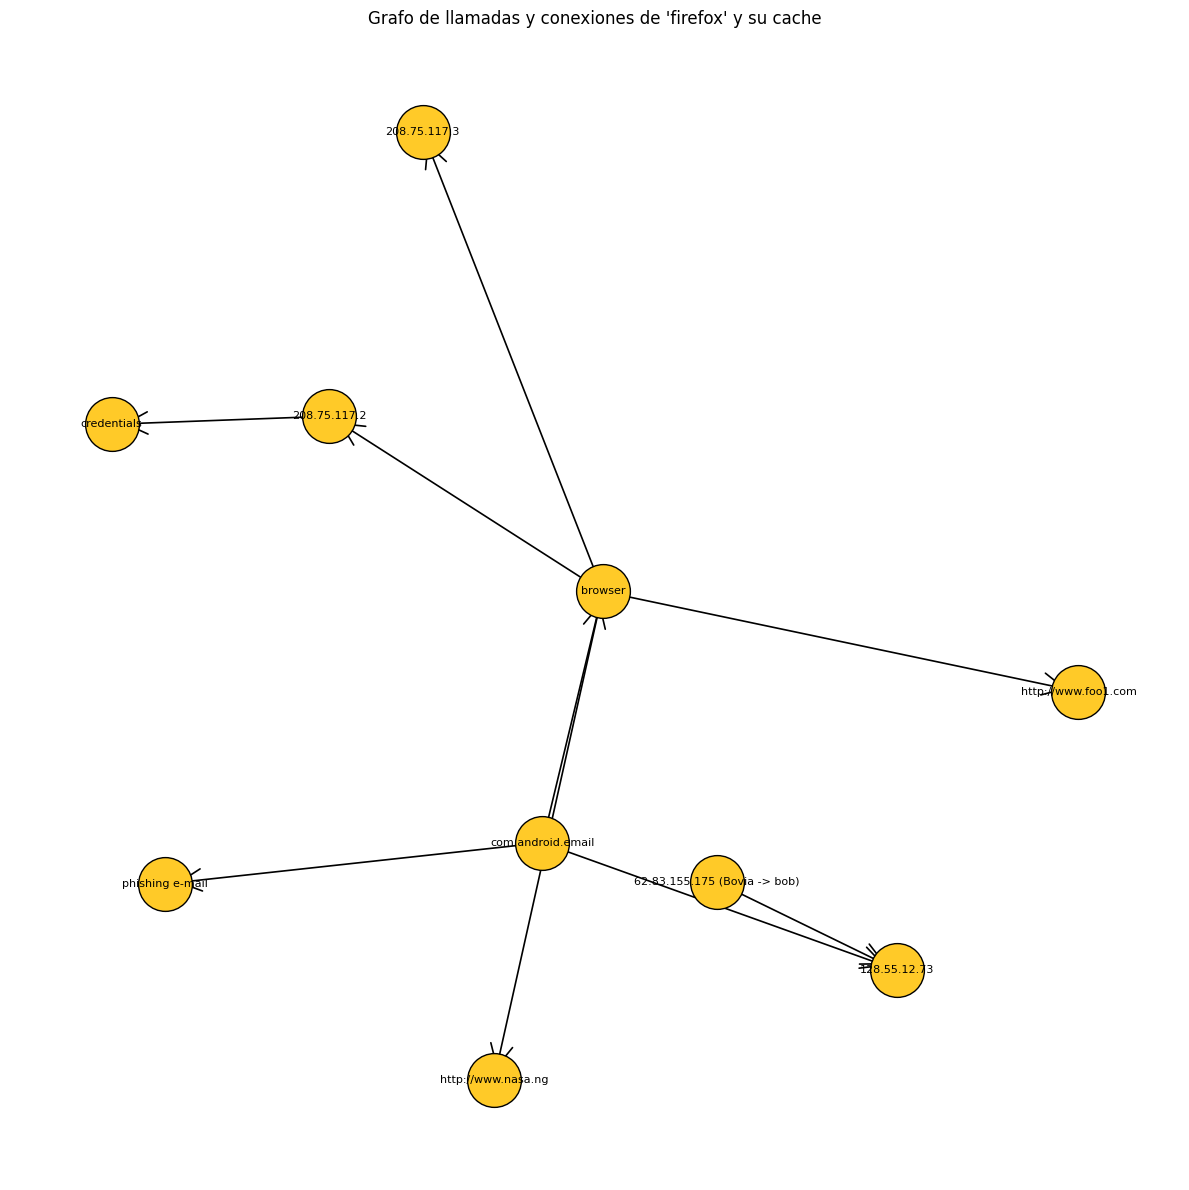

In [32]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Procesos
G.add_node("browser",         shape="rectangle")
G.add_node("com.android.email", shape="rectangle")

# Ficheros / datos
G.add_node("phishing e-mail", shape="ellipse")
G.add_node("credentials",     shape="ellipse")

# IPs y URLs (conexiones)
G.add_node("208.75.117.2",                   shape="diamond")
G.add_node("208.75.117.3",                   shape="diamond")
G.add_node("http://www.foo1.com",            shape="diamond")
G.add_node("http://www.nasa.ng",             shape="diamond")
G.add_node("62.83.155.175 (Bovia -> bob)",   shape="diamond")
G.add_node("128.55.12.73",                   shape="diamond")

# --- ARISTAS con atributo "action" ---
# Flujo de exfiltración de credenciales
G.add_edge("browser",       "208.75.117.2",     action="connect")
G.add_edge("browser",       "208.75.117.3",     action="connect")
G.add_edge("208.75.117.2",  "credentials",      action="open")
G.add_edge("browser",   "http://www.foo1.com", action="connect")
G.add_edge("browser",       "http://www.nasa.ng",  action="connect")

# Flujo de correo en Android
G.add_edge("com.android.email", "browser",                    action="open")
G.add_edge("com.android.email", "phishing e-mail",            action="read")
G.add_edge("com.android.email", "128.55.12.73",               action="connect")
G.add_edge("62.83.155.175 (Bovia -> bob)", "128.55.12.73",   action="connect")




draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_2.gml")


4.4.4
TBD

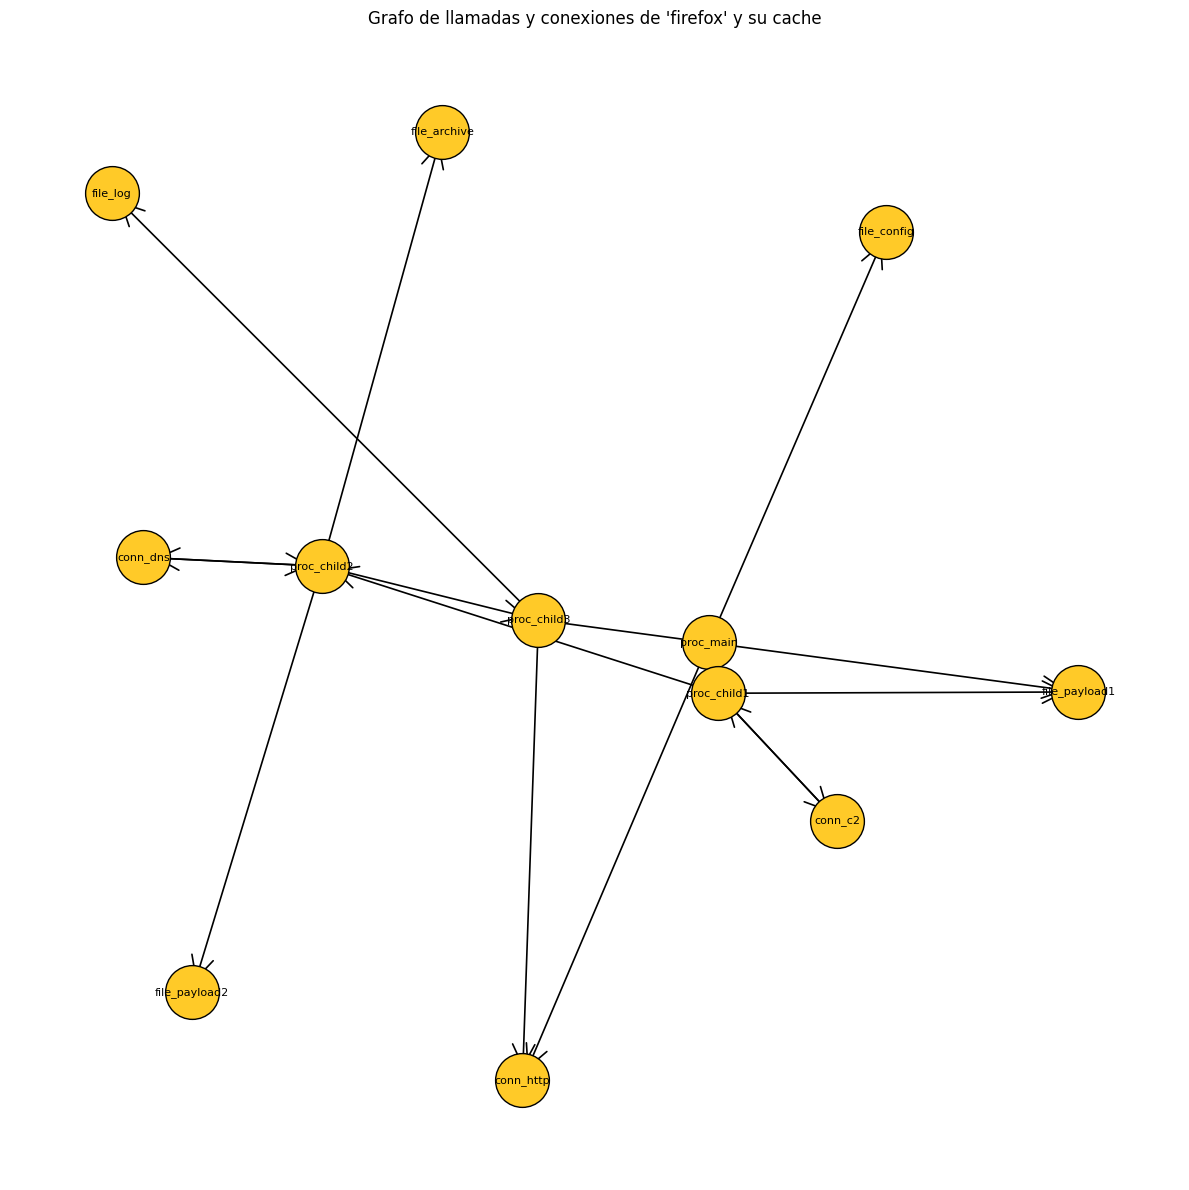

In [30]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# -----------------------
# 1️⃣  Define the nodes
# -----------------------
nodes = {
    # Processes (rectangle)
    "proc_main":     {"shape": "rectangle"},
    "proc_child1":   {"shape": "rectangle"},
    "proc_child2":   {"shape": "rectangle"},
    "proc_child3":   {"shape": "rectangle"},

    # Files (ellipse)
    "file_config":   {"shape": "ellipse"},
    "file_log":      {"shape": "ellipse"},
    "file_payload1": {"shape": "ellipse"},
    "file_payload2": {"shape": "ellipse"},
    "file_archive":  {"shape": "ellipse"},

    # Connections / URLs / IPs (diamond)
    "conn_http": {"shape": "diamond"},
    "conn_c2":   {"shape": "diamond"},
    "conn_dns":  {"shape": "diamond"},
}

# Add the nodes with their attributes
G.add_nodes_from([(n, attrs) for n, attrs in nodes.items()])

# -----------------------
# 2️⃣  Define the edges
# -----------------------
edges = [
    ("proc_main",   "conn_http",   {"action": "connect"}),
    ("proc_main",   "file_config", {"action": "read"}),
    ("proc_main",   "proc_child1", {"action": "execute"}),

    ("proc_child1", "file_payload1", {"action": "write"}),
    ("proc_child1", "conn_c2",       {"action": "send"}),
    ("conn_c2",     "proc_child1",   {"action": "receive"}),

    ("proc_child1", "proc_child2",   {"action": "execute"}),

    ("proc_child2", "file_payload2", {"action": "write"}),
    ("proc_child2", "file_archive",  {"action": "write"}),
    ("proc_child2", "conn_dns",      {"action": "send"}),
    ("conn_dns",    "proc_child2",   {"action": "receive"}),

    ("proc_child2", "proc_child3",   {"action": "execute"}),

    ("proc_child3", "file_log",      {"action": "write"}),
    ("proc_child3", "file_payload1", {"action": "read"}),
    ("proc_child3", "conn_http",     {"action": "send"}),
]

# Add the edges with their attributes
G.add_edges_from(edges)




draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_4.gml")


4.5.5

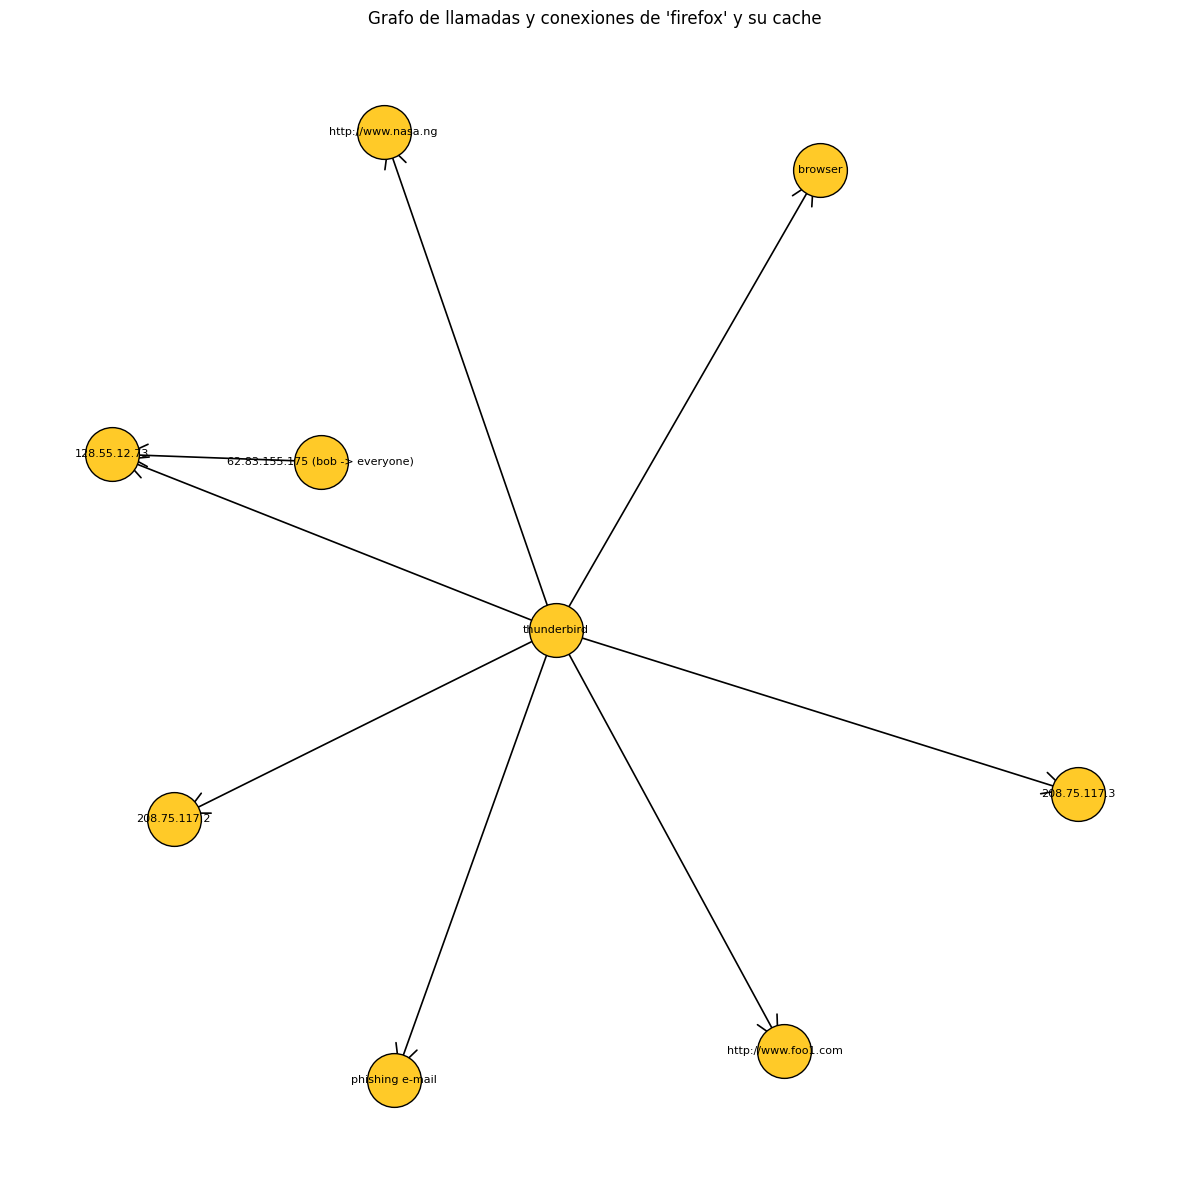

In [29]:
import networkx as nx

# Creamos un grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Procesos
G.add_node("browser",    shape="rectangle")
G.add_node("thunderbird",shape="rectangle")

# Ficheros
G.add_node("phishing e-mail", shape="ellipse")

# IPs y URLs (conexiones)
G.add_node("128.55.12.73",             shape="diamond")
G.add_node("62.83.155.175 (bob -> everyone)", shape="diamond")
G.add_node("http://www.nasa.ng",       shape="diamond")
G.add_node("208.75.117.3",             shape="diamond")
G.add_node("http://www.foo1.com",      shape="diamond")
G.add_node("208.75.117.2",             shape="diamond")

# --- ARISTAS con atributo "action" ---
# Flujo de Thunderbird
G.add_edge("thunderbird", "phishing e-mail", action="read")
G.add_edge("thunderbird", "128.55.12.73",      action="connect")
G.add_edge("62.83.155.175 (bob -> everyone)", "128.55.12.73",
           action="connect")

# Flujo de Browser
G.add_edge("thunderbird", "browser", action="open")
G.add_edge("thunderbird", "http://www.nasa.ng", action="connect")
G.add_edge("thunderbird", "208.75.117.3",   action="connect")
G.add_edge("thunderbird", "http://www.foo1.com", action="connect")
G.add_edge("thunderbird", "208.75.117.2",   action="connect")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_5.gml")

4.6.5

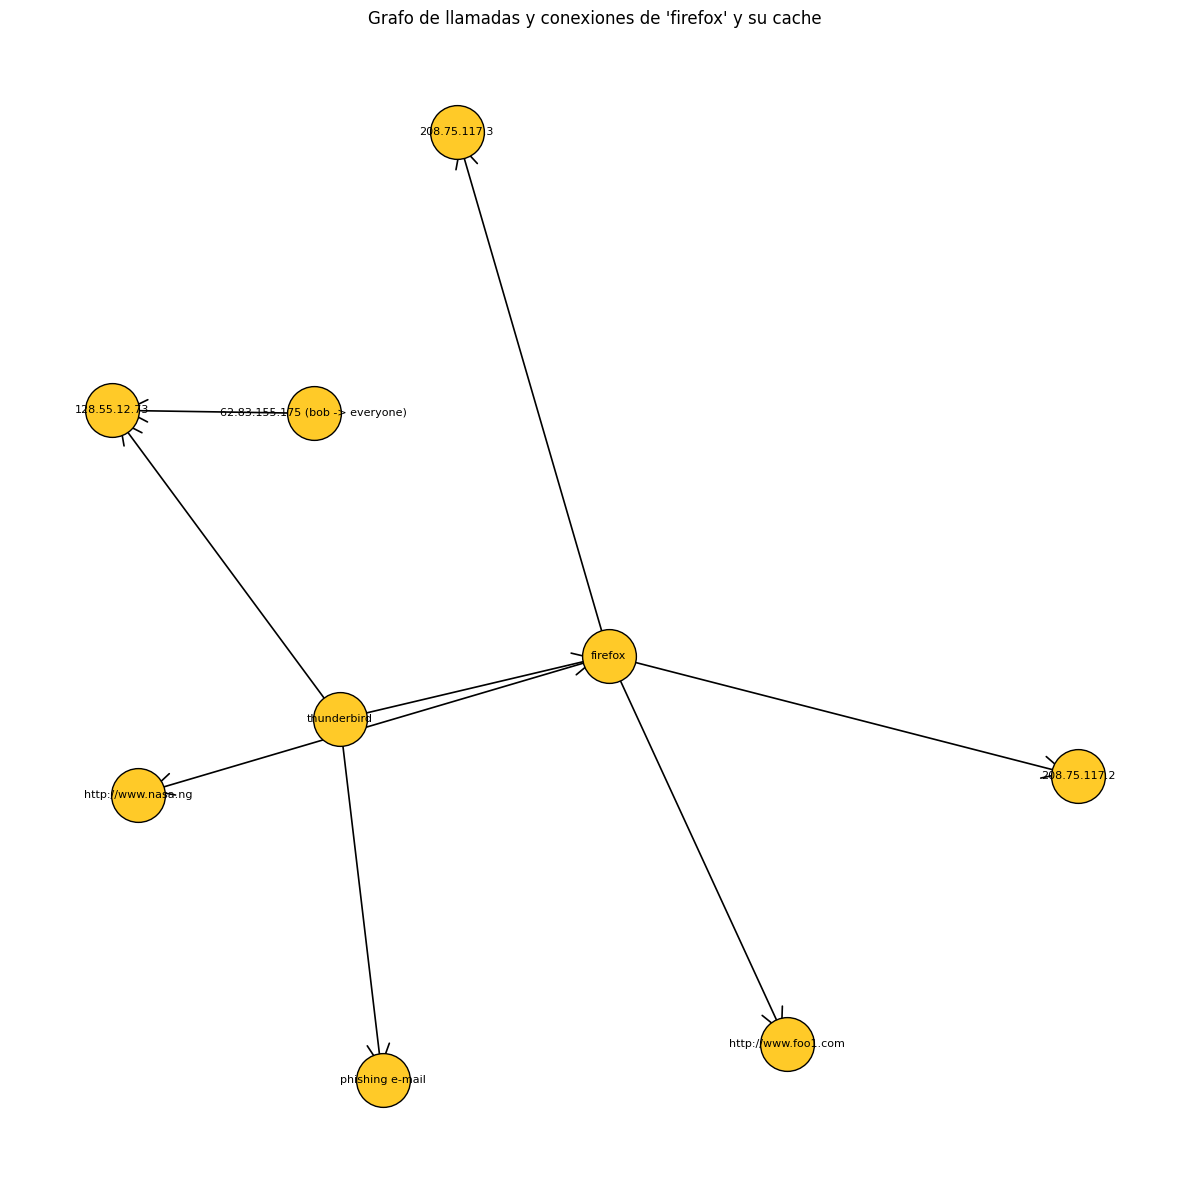

In [26]:
import networkx as nx

# Crear grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Procesos
G.add_node("thunderbird", shape="rectangle")
G.add_node("firefox",     shape="rectangle")

# Ficheros
G.add_node("phishing e-mail", shape="ellipse")

# IPs y URLs (conexiones)
G.add_node("128.55.12.73",       shape="diamond")
G.add_node("62.83.155.175 (bob -> everyone)", shape="diamond")
G.add_node("208.75.117.3",       shape="diamond")
G.add_node("208.75.117.2",       shape="diamond")
G.add_node("http://www.foo1.com", shape="diamond")
G.add_node("http://www.nasa.ng",  shape="diamond")

# --- ARISTAS con atributo "action" ---
# Rama izquierda
G.add_edge("thunderbird", "phishing e-mail", action="read")
G.add_edge("thunderbird", "128.55.12.73",      action="connect")
G.add_edge("62.83.155.175 (bob -> everyone)", "128.55.12.73", action="connect")

# Rama derecha
G.add_edge("thunderbird", "firefox", action="open")
G.add_edge("firefox",     "208.75.117.3",       action="connect")
G.add_edge("firefox",     "http://www.foo1.com", action="connect")
G.add_edge("firefox",     "208.75.117.2",       action="connect")
G.add_edge("firefox",     "http://www.nasa.ng",  action="connect")


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_6.gml")


4.8.4

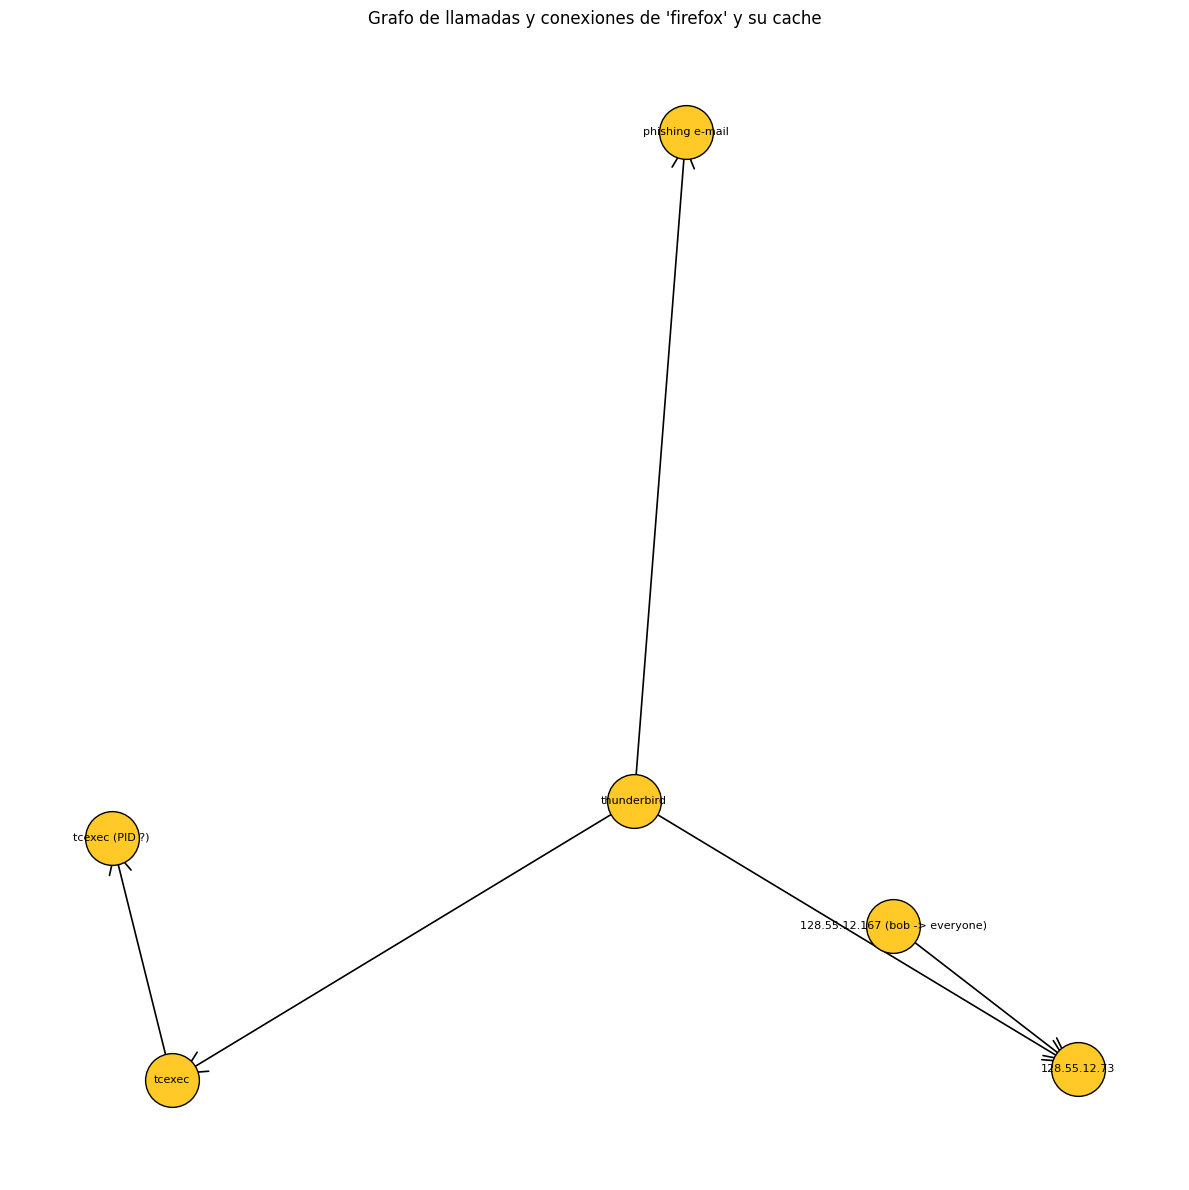

In [24]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# Añadir nodos con su atributo "shape"
G.add_node("phishing e-mail", shape="ellipse")                   # fichero
G.add_node("thunderbird", shape="rectangle")                     # proceso
G.add_node("tcexec", shape="rectangle")                          # proceso hijo
G.add_node("tcexec (PID ?)", shape="rectangle")                  # proceso que crashea
G.add_node("128.55.12.73", shape="diamond")                      # conexión/IP
G.add_node("128.55.12.167 (bob -> everyone)", shape="diamond")   # conexión/IP

# Añadir aristas con su atributo "action"
G.add_edge("thunderbird", "phishing e-mail", action="read")
G.add_edge("thunderbird", "tcexec", action="execute")
G.add_edge("tcexec", "tcexec (PID ?)", action="create")
G.add_edge("tcexec (PID ?)", "tcexec (PID ?)", action="execute")
G.add_edge("thunderbird", "128.55.12.73", action="connect")
G.add_edge("128.55.12.167 (bob -> everyone)", "128.55.12.73",
           action="connect")


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_8.gml")


4.9.5

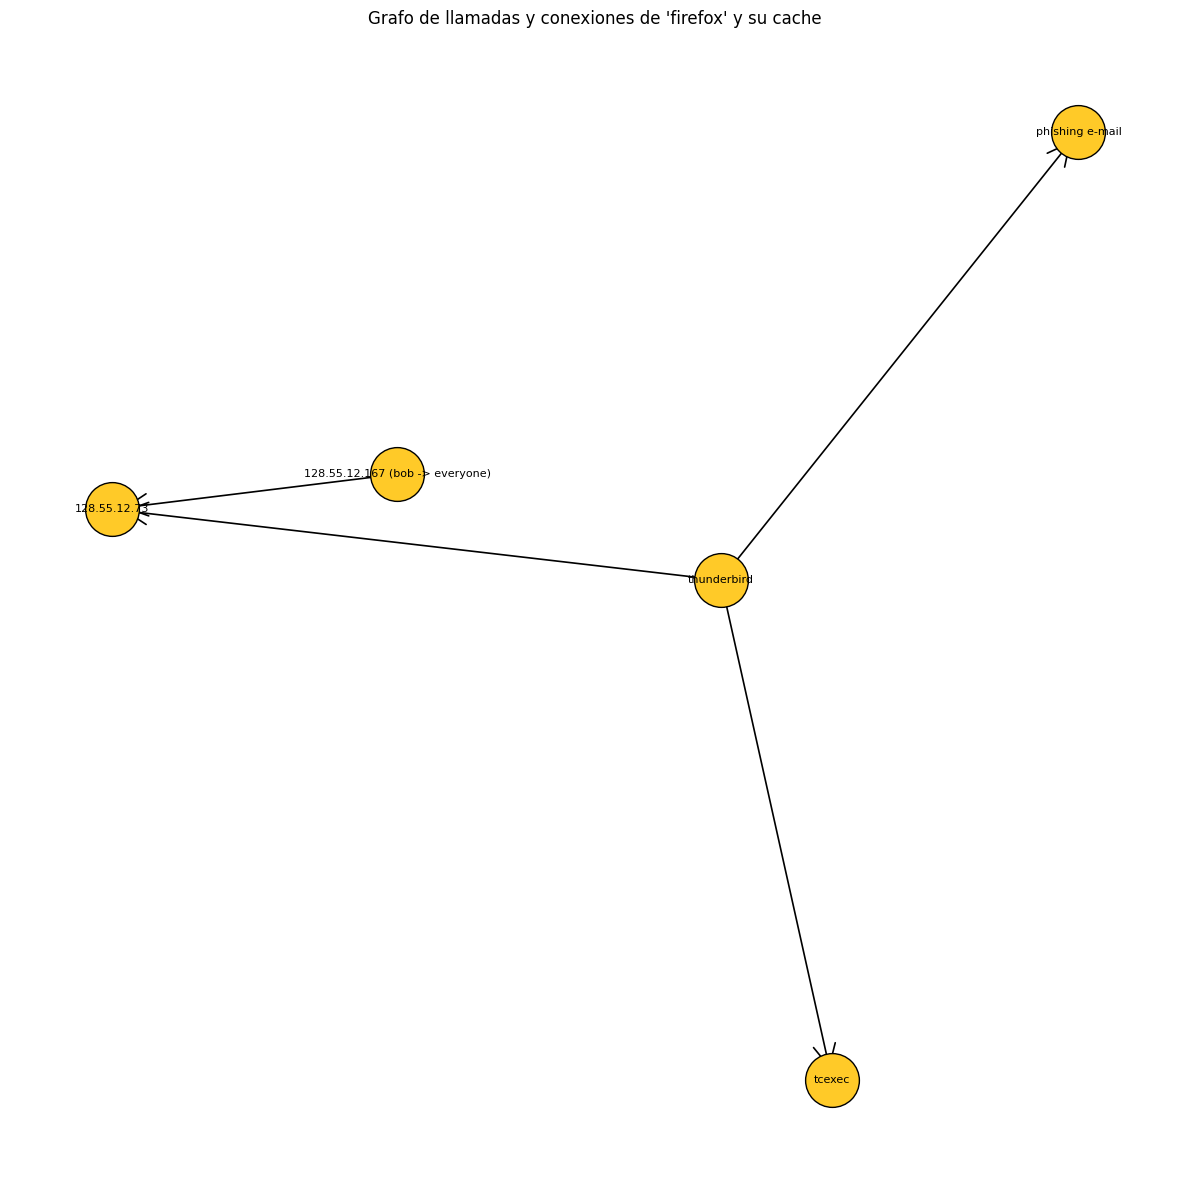

In [21]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# Añadir nodos con su atributo "shape"
G.add_node("phishing e-mail", shape="ellipse")                            # fichero
G.add_node("thunderbird", shape="rectangle")                              # proceso
G.add_node("tcexec", shape="rectangle")                                   # proceso
G.add_node("128.55.12.73", shape="diamond")                               # conexión/IP
G.add_node("128.55.12.167 (bob -> everyone)", shape="diamond")            # conexión/IP

# Añadir aristas con su atributo "action"
G.add_edge("thunderbird", "phishing e-mail", action="read")
G.add_edge("thunderbird", "tcexec", action="execute")
G.add_edge("tcexec", "tcexec", action="execute")
G.add_edge("thunderbird", "128.55.12.73", action="connect")
G.add_edge("128.55.12.167 (bob -> everyone)", "128.55.12.73",
           action="connect")

draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_9.gml")